# Practical Session Geospatial_data_analysis

**@author : Ilyann Mouisset--Ferrara**

**@group : APP-BDML2-2025034**

**@email : ilyann.mouisset--ferrara@efrei.fr**




In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import folium

path ="uber-raw-data-apr14.csv"

df = pd.read_csv(path,delimiter=",")
print(df.head())
print(df.info())

          Date/Time      Lat      Lon    Base
0  4/1/2014 0:11:00  40.7690 -73.9549  B02512
1  4/1/2014 0:17:00  40.7267 -74.0345  B02512
2  4/1/2014 0:21:00  40.7316 -73.9873  B02512
3  4/1/2014 0:28:00  40.7588 -73.9776  B02512
4  4/1/2014 0:33:00  40.7594 -73.9722  B02512
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB
None


# Mapping Date

In [5]:
def get_dom(dt):
    return dt.day #.day is an attribut of datetime object

def hour(dt):
    return dt.hour

def get_weekday(dt):
    return dt.weekday()

df["Date/Time"] = pd.to_datetime(df["Date/Time"])

df['day'] = df['Date/Time'].map(get_dom)
df['weekday'] = df['Date/Time'].map(get_weekday)
df['hour'] = df['Date/Time'].map(hour)

df


,Date/Time,Lat,Lon,Base,day,weekday,hour
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,1,1,0
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,1,1,0
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,1,1,0
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,1,1,0
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,1,1,0
...,...,...,...,...,...,...,...
564511,2014-04-30 23:22:00,40.7640,-73.9744,B02764,30,2,23
564512,2014-04-30 23:26:00,40.7629,-73.9672,B02764,30,2,23
564513,2014-04-30 23:31:00,40.7443,-73.9889,B02764,30,2,23
564514,2014-04-30 23:32:00,40.6756,-73.9405,B02764,30,2,23


# Create Histogramme

Text(0.5, 0, 'Days of the month')

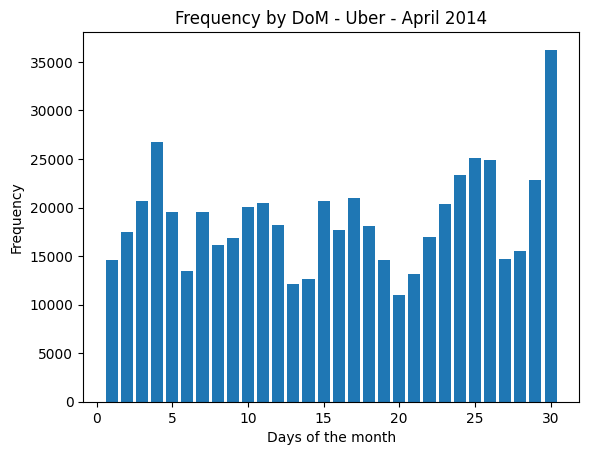

In [4]:
hist = df["day"].plot.hist(bins = 30, rwidth = 0.8, range=(0.5,30.5), title = "Frequency by DoM - Uber - April 2014")
plt.xlabel('Days of the month')
#binsint or sequence or str, default: rcParams["hist.bins"] (default: 10)
#If bins is an integer, it defines the number of equal-width bins in the range.
#If bins is a sequence, it defines the bin edges, including the left edge of the first bin
#and the right edge of the last bin; in this case, bins may be unequally spaced.

## Creating a function for Grouping the data by date of month (dom) example: def count_rows(rows): return len(rows)


C:\Users\ilyan\AppData\Local\Temp\ipykernel_3316\1507906861.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_date = df.groupby('day').apply(count_rows)


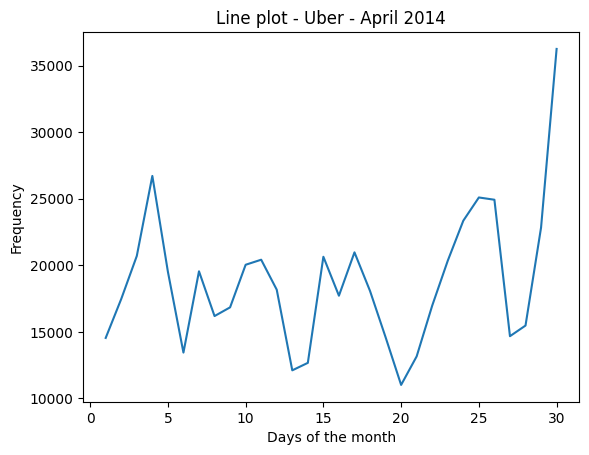

In [5]:
def count_rows(rows):
    return len(rows)

by_date = df.groupby('day').apply(count_rows)

plt.title('Line plot - Uber - April 2014')
plt.xlabel('Days of the month')
plt.ylabel('Frequency')
plt.plot(by_date)

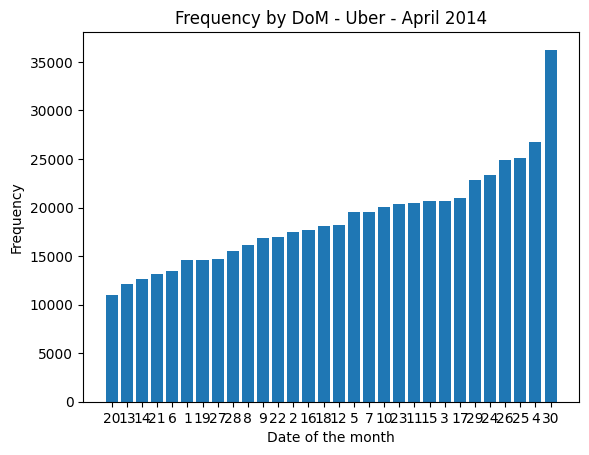

In [6]:
plt.bar(range(1, 31), by_date.sort_values())
plt.xticks(range(1, 31), by_date.sort_values().index)
plt.xlabel('Date of the month')
plt.ylabel('Frequency')
plt.title('Frequency by DoM - Uber - April 2014');

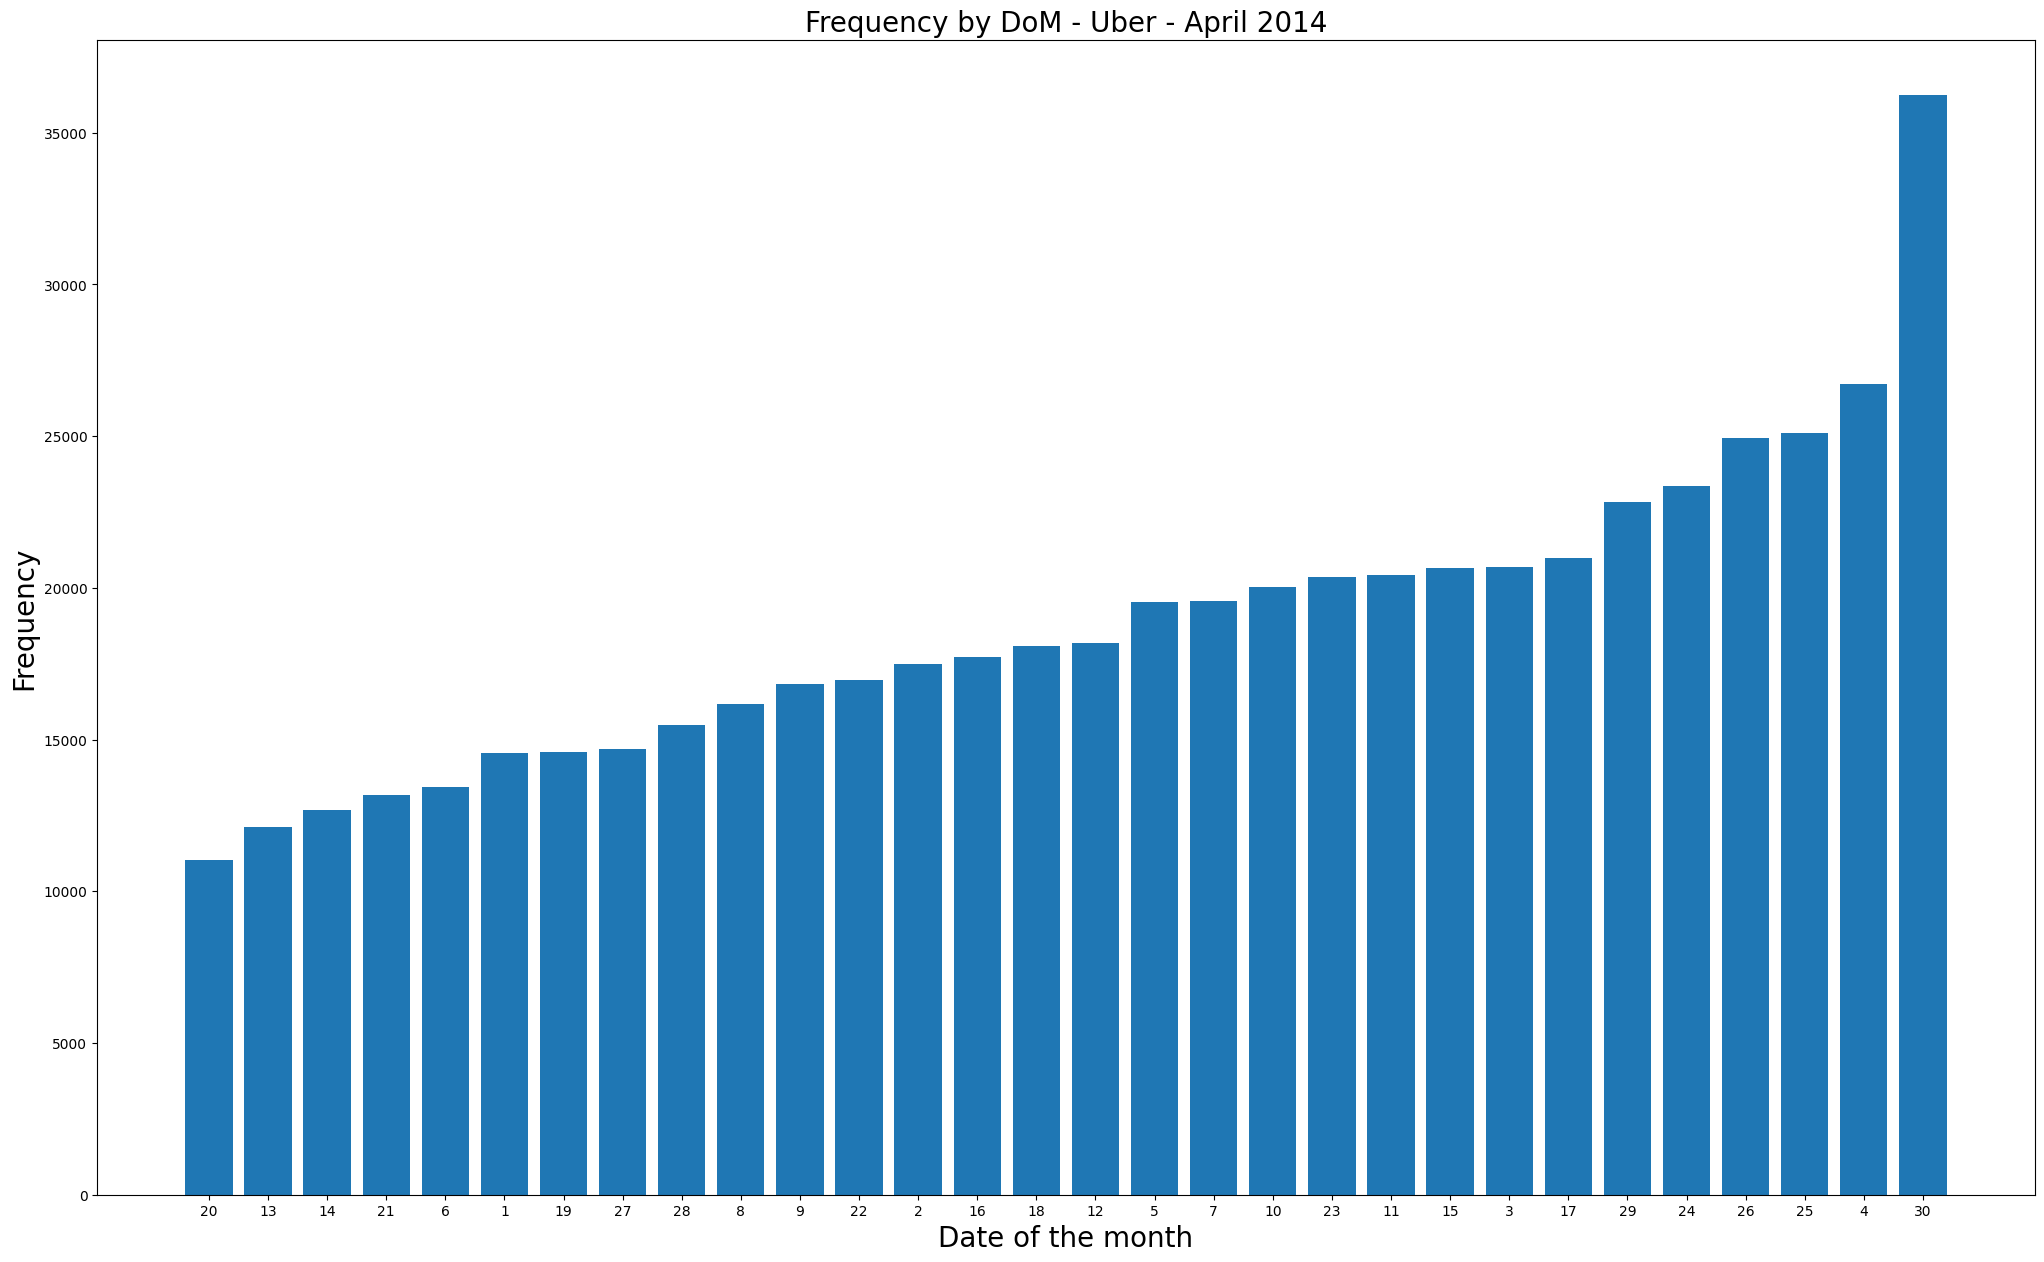

In [7]:
plt.figure(figsize = (25, 15))
plt.bar(range(1, 31), by_date.sort_values())
plt.xticks(range(1, 31), by_date.sort_values().index)
plt.xlabel(('Date of the month'), fontsize=20)
plt.ylabel(('Frequency'), fontsize=20)
plt.title(('Frequency by DoM - Uber - April 2014'), fontsize=20);

## Visualise the data by hours using histogram with bins=24,range=(0.5,24)

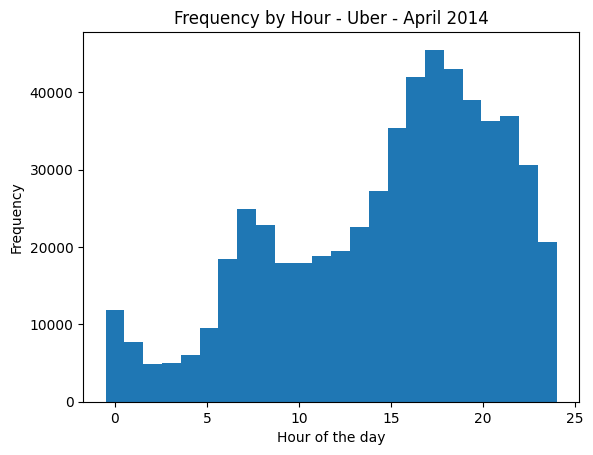

In [8]:

plt.hist(df.hour, bins = 24, range = (-0.5, 24))
plt.xlabel('Hour of the day')
plt.ylabel('Frequency')
plt.title('Frequency by Hour - Uber - April 2014');

## Check the use of xticks and add 'Mon Tue Wed Thu Fri Sat Sun'.split()

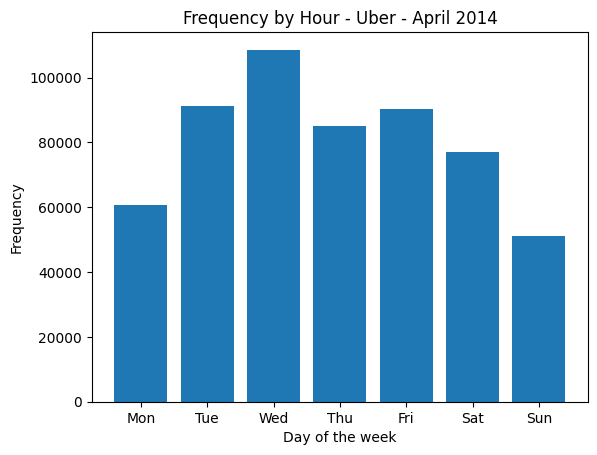

In [9]:

plt.hist(df.weekday, bins = 7, rwidth = 0.8, range = (-.5, 6.5))
plt.xlabel('Day of the week')
plt.ylabel('Frequency')
plt.title('Frequency by Hour - Uber - April 2014')
plt.xticks(np.arange(7), 'Mon Tue Wed Thu Fri Sat Sun'.split())
plt.show()

In [10]:
df2 = df.groupby(['weekday', 'hour']).apply(count_rows).unstack()
df2.head()
#Pandas Unstack is a function that pivots the level of the indexed columns in a stacked dataframe. 
#A stacked dataframe is usually a result of an aggregated groupby function in pandas.
#Stack() sets the columns to a new level of hierarchy whereas Unstack() pivots the indexed column.

C:\Users\ilyan\AppData\Local\Temp\ipykernel_3316\2720920564.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2 = df.groupby(['weekday', 'hour']).apply(count_rows).unstack()


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,518,261,238,571,1021,1619,2974,3888,3138,2211,...,3117,3818,4962,5574,4725,4386,3573,3079,1976,1091
1,765,367,304,516,887,1734,3766,5304,4594,2962,...,4489,6042,7521,8297,7089,6459,6310,5993,3614,1948
2,899,507,371,585,1003,1990,4230,5647,5242,3846,...,5438,7071,8213,9151,8334,7794,7783,6921,4845,2571
3,792,459,342,567,861,1454,3179,4159,3616,2654,...,4083,5182,6149,6951,6637,5929,6345,6585,5370,2909
4,1367,760,513,736,932,1382,2836,3943,3648,2732,...,4087,5354,6259,6790,7258,6247,5165,6265,6708,5393


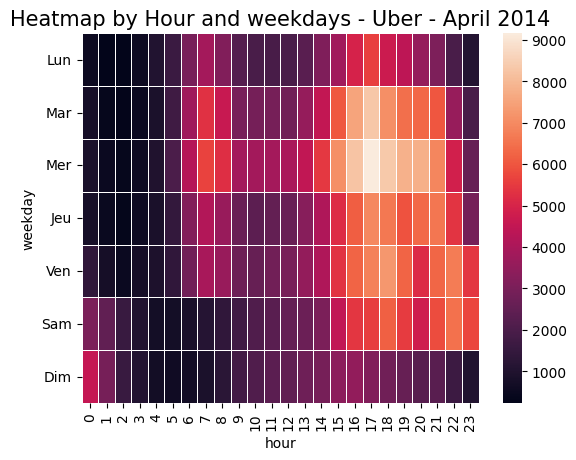

In [11]:
heatmap = sns.heatmap(df2, linewidths = .5)

plt.title('Heatmap by Hour and weekdays - Uber - April 2014',fontsize=15)
heatmap.set_yticklabels(('Lun Mar Mer Jeu Ven Sam Dim').split(), rotation='horizontal');

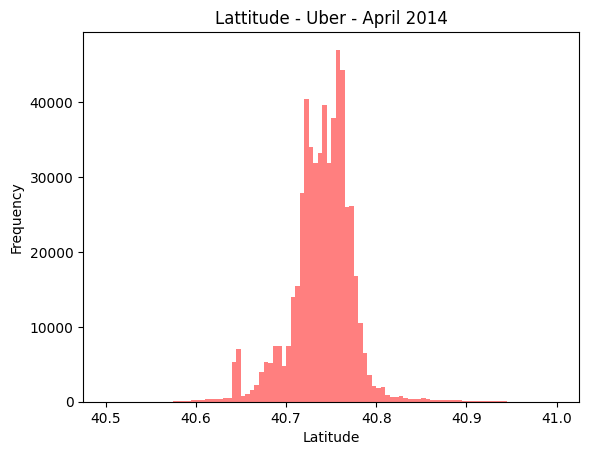

In [12]:
#Lat :
plt.hist(df['Lat'], bins = 100, range = (40.5, 41), color = 'r',alpha = 0.5, label = 'Latitude')
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Lattitude - Uber - April 2014');
plt.show()

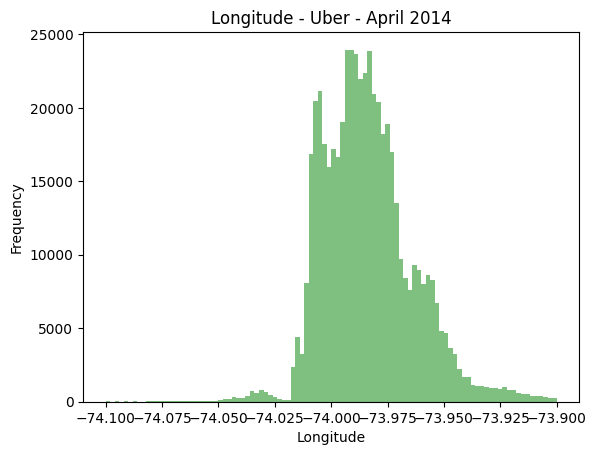

In [13]:
#Lon :
plt.hist(df['Lon'], bins = 100, range = (-74.1, -73.9), color = 'g', alpha = 0.5, label = 'Longitude')
plt.xlabel('Longitude')
plt.ylabel('Frequency')
plt.title('Longitude - Uber - April 2014');
plt.show()

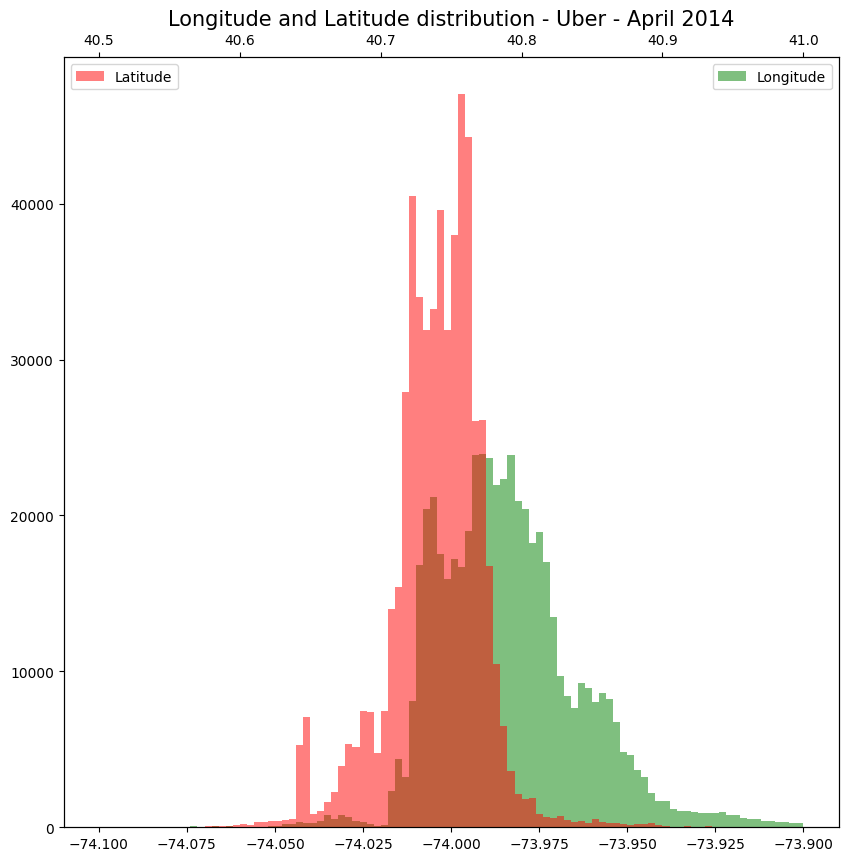

In [14]:
plt.figure(figsize=(10, 10), dpi=100)
plt.title('Longitude and Latitude distribution - Uber - April 2014',fontsize=15)
plt.hist(df['Lon'], bins = 100, range = (-74.1, -73.9), color = 'g', alpha = 0.5, label = 'Longitude')
plt.legend(loc = 'best')
plt.twiny()
plt.hist(df['Lat'], bins = 100, range = (40.5, 41), color = 'r',alpha = 0.5, label = 'Latitude')
plt.legend(loc = 'upper left')
plt.show()

(40.7, 40.9)

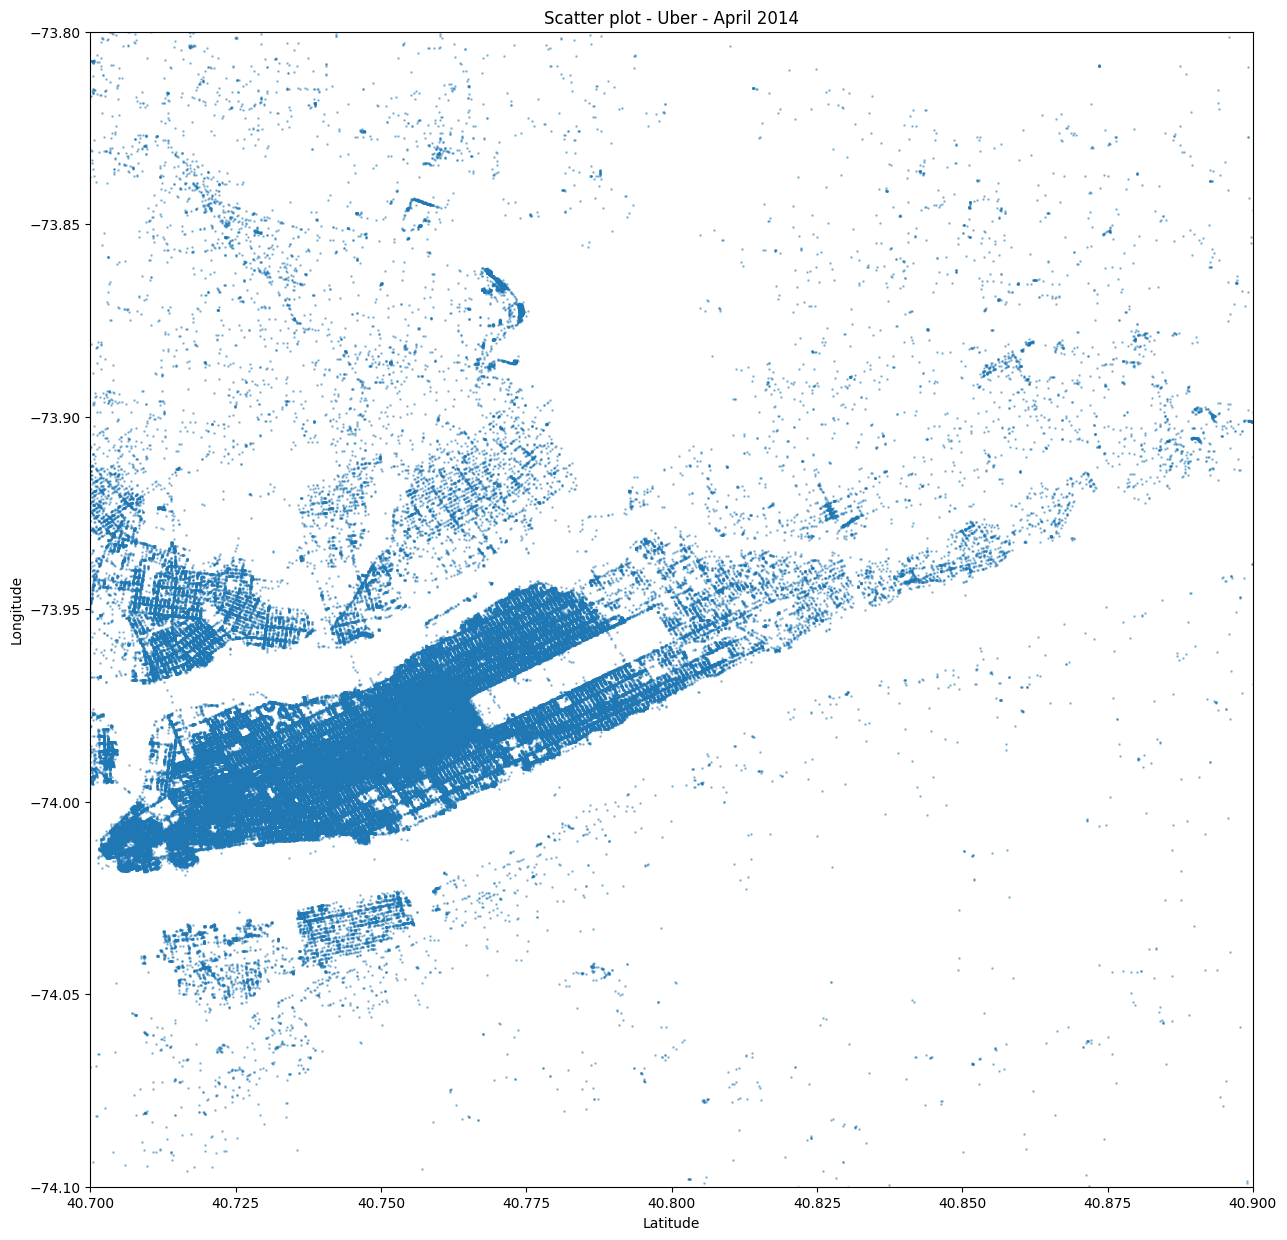

In [15]:
plt.figure(figsize=(15, 15), dpi=100)
plt.title('Scatter plot - Uber - April 2014')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.scatter(df['Lat'],df['Lon'],s=0.8,alpha=0.4) #Without list also shows the same plot
plt.ylim(-74.1, -73.8)
plt.xlim(40.7, 40.9)


# Try exploring the same data using any from below:
https://python-visualization.github.io/folium/latest/getting_started.html
https://holoviews.org/gallery/demos/bokeh/texas_choropleth_example.html
 
https://plotly.com/python/bubble-maps/

In [16]:

map_center = [df['Lat'].mean(), df['Lon'].mean()]
m = folium.Map(location=map_center, zoom_start=12)

# Use only 1000 random points for speed
for idx, row in df.sample(5000).iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=1,
        color='blue',
        fill=True,
        fill_opacity=0.5
    ).add_to(m)

m